<a href="https://colab.research.google.com/github/perrymason-droid/ores5160-2026/blob/main/week9/week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


In [4]:
from google.colab import files

uploaded = files.upload()  # This will open a file picker

Saving est2018-pop-res.csv to est2018-pop-res.csv


In [6]:
# Q1: Reading the CSV File

import csv
import pandas as pd

# File path (uploaded to Colab)
file_path = "est2018-pop-res.csv"

# 1. Using csv module to print first 5 rows
print("=== First 5 rows using csv module ===\n")
with open(file_path, 'r') as file:
    reader = csv.reader(file)
    for i, row in enumerate(reader):
        print(row)
        if i == 4:  # stop after 5 rows
            break

# 2. Loading data with pandas
print("\n=== Loading data with pandas ===\n")
df = pd.read_csv(file_path)

# Display shape
print("Shape of dataset:", df.shape)

# Print column names
print("\nColumn names:")
print(df.columns.tolist())

# 3. Display top 5 most populous states
print("\n=== Top 5 most populous states ===\n")
top_states = df.sort_values(by="POPESTIMATE2018", ascending=False)
print(top_states[["NAME", "POPESTIMATE2018"]].head())

=== First 5 rows using csv module ===

['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']
['010', '0', '0', '00', 'United States', '327167434', '253768092', '77.6']
['040', '3', '6', '01', 'Alabama', '4887871', '3798031', '77.7']
['040', '4', '9', '02', 'Alaska', '737438', '553622', '75.1']
['040', '4', '8', '04', 'Arizona', '7171646', '5528989', '77.1']

=== Loading data with pandas ===

Shape of dataset: (53, 8)

Column names:
['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']

=== Top 5 most populous states ===

             NAME  POPESTIMATE2018
0   United States        327167434
5      California         39557045
44          Texas         28701845
10        Florida         21299325
33       New York         19542209


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

Average population across states: 12406226.811320756

Population by region:
REGION
0    327167434
1     56111079
2     68308744
3    124753948
4     77993663
X      3195153
Name: POPESTIMATE2018, dtype: int64

Region with highest population: 0


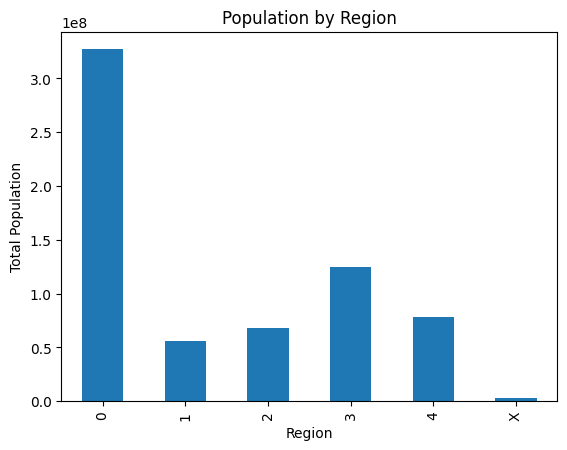

In [7]:
# Q2: Basic Statistical Analysis

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("est2018-pop-res.csv")

# 1. Average population across states
average_population = df["POPESTIMATE2018"].mean()
print("Average population across states:", average_population)

# 2. Region with highest population
region_population = df.groupby("REGION")["POPESTIMATE2018"].sum()

print("\nPopulation by region:")
print(region_population)

print("\nRegion with highest population:", region_population.idxmax())

# 3. Bar chart of population by region
region_population.plot(kind="bar")

plt.title("Population by Region")
plt.xlabel("Region")
plt.ylabel("Total Population")
plt.show()

Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

In [11]:
from google.colab import files

uploaded = files.upload()  # This will open a file picker

Saving patient.json to patient (1).json


In [9]:
# Q3: Parsing the JSON File

import json

# JSON file uploaded to Colab
json_file_path = "patient.json"

with open(json_file_path, 'r') as f:
    patient = json.load(f)

# Patient full official name
name = patient["name"][0]
full_name = " ".join(name["given"]) + " " + name["family"]
print("Patient Full Name:", full_name)

# Gender and birth date
print("Gender:", patient["gender"])
print("Birth Date:", patient["birthDate"])

# Current address
address = patient["address"][0]
print("\nAddress:")
print("City:", address["city"])
print("State:", address["state"])
print("Postal Code:", address["postalCode"])

# Count phone numbers and list their types
telecom = patient["telecom"]
print("\nNumber of phone numbers:", len(telecom))
phone_types = [t["use"] for t in telecom]
print("Phone types:", phone_types)

FileNotFoundError: [Errno 2] No such file or directory: 'patient.json'